# **1 CSE351 - Project #1: Movie Revenue Prediction**

Hochan Jun   
Woochul Lim  

### Contributions

**Hochan Jun**
- Preprocessing (Cleaning the dataset) **numerical values**
- Solved 2 EDA problems: the movie genre trend shifting patterns, ROI & Analysis
- Modeling: simple linear regression model - testing and training + visualization
- Analysis on Case 1: Splitting data by the decades (70% training, 30% testing) => **before 2010 / after 2010 (including 2010)**
- Drawing a conclusion 
- Presentation slides

**Woochul Lim**
- Preprocessing (Cleaning the dataset ) **non-numerical values**
- Extracted the number of crews, the average revenue per country and company from non-neumeric data.
- Solved 2 EDA problems: the number of movies released by time periods, Strongest and weakest feautures correlated with Revenue.
- Modeling: multiple linear regression model, polynomial ridge regression - testing and training + visualization
- Analysis on Case 2: Splitting data by **random** (70% training, 30% testing)
- Summarizing RSE results
- Documentation


In [115]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import ast

In [116]:
# read the data
movies = pd.read_csv('./movie/tmdb_5000_movies.csv')
credits = pd.read_csv('./movie/tmdb_5000_credits.csv')

# **2 Preprocessing (Non-numeric Values)**

Handling missing or invalid attributes in the data is essential for improving performace of models.  
Several features in the original data are non-numerical and cannot be imputed using statistical methods such as mean, median, and random sampling, or imputation based on linear regression. Therefore these rows must be excluded.

The following attributes will be handled as dealing with non-numerical features:

In 'tmdb_5000_movies.csv'
- genres
- original_language
- prouction_companies
- production_countries
- release_date
- status

In tmdb_5000_credits.csv:
- cast
- crew

Since these features are not numeric, several imputation methods mentioned above are not applicable.  
Therefore, rows containing invalid values will be excluded while training models.

Unreleased movies (status as 'unreleased' or 'post production') will also be excluded since these movies do not have revenue to train models.

In [117]:
########## tmdb_5000_movies.csv ##########

# no movies with genres of NaN
movies[movies['genres'].isna()]

# Movies with empty genres will be excluded while traning models.
# This is not a numerical value so the imputation methods are not available.
movies = movies[movies['genres'] != '[]']

# no movies with original_language of NaN
movies[movies['original_language'].isna()]

# no movies with original_language of NaN
movies[movies['production_companies'].isna()]

# Movies with empty production_companies will be excluded while traning models.
# This is not a numerical value so the imputation methods are not available.
movies =  movies[movies['production_companies'] != '[]']

# no movies with original_language of NaN
movies[movies['production_countries'].isna()]
movies =  movies[movies['production_countries'] != '[]']

# movies with release_date of NaN must be deleted in preprocessing,
# imputation methods (average, random value, linear regression) would not 
# work well for the date data type.
# This attribute is actually not a numerical value, so it will be meaingless 
# to fill this attribute with the mean, a random value, or a value from linear regression.
movies = movies[movies['release_date'].notna()]

# no movies with status of NaN
movies[movies['status'].isna()]

# Movies with only released status will be used to train models  
# and movies having post production and rumored will be used to test the models.
# This is logically sensible to predict the revenue of unreleased movies, and 
# exclude them while training.
movies = movies[movies['status'] == 'Released']

In [118]:
########## tmdb_5000_credits.csv ##########

# This is logically difficult to do imputation on 'cast' attribute 
# since this is not a single numerical value.
# movies with 0 cast will be excluded while training.

# no movies with cast of 0 or NaN.
credits[credits['cast'].apply(len) != 0]
credits[credits['cast'].notna()]

# This is logically difficult to do imputation on 'crew' attribute 
# since this is not a single numerical value.
# movies with 0 crew will be excluded while training.

# no movies with crew of 0 or NaN.
credits[credits['crew'].apply(len) != 0]
credits[credits['crew'].isna()]


,movie_id,title,cast,crew


# **3 Preprocessing (Numeric Values)**

Before we started to analyze the numeric data, we eliminated or managed the values below:

(1) zeros, null (NaN), and negative values.

(2) out of range (e.g. ratings more than 10 out of 10).

We regarded these would be inappropriate the anlaysis process.
***
There were no negative values at all, so two types of actions regarding (1) were made:

- Budget and revenue zeros are deleted from the training set for more accurate model training, but are going to be used in testing set. They are too many just to be eliminated totally from the whole part.
- For vote_average, nothing was changed because we found out that some movies are actually have not been voted or graded even once.
- Other ones are eliminated.

In [119]:
# Made a new df for checking the values
numeric = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count' ]
movies[numeric] = movies[numeric].apply(pd.to_numeric, errors='coerce')

numericDf = movies.select_dtypes(include=['number'])

zero = (numericDf == 0).sum()
nan = numericDf.isna().sum()
negative = (numericDf < 0).sum()

countsDf = pd.DataFrame({
    "zeroCount": zero,
    "nanCount": nan,
    "negCount": negative
})

countsDf

,zeroCount,nanCount,negCount
budget,759,0,0
id,0,0,0
popularity,0,0,0
revenue,1108,0,0
runtime,5,2,0
vote_average,23,0,0
vote_count,23,0,0


In [120]:
# Drop NaN / null from numeric values 
movies = movies.dropna(subset=numeric)

# Drop Zero values from budget, popularity, revenue, runtime, vote_count
movies = movies[movies["budget"] > 0]
movies = movies[movies["popularity"] > 0]
movies = movies[movies["revenue"] > 0]
movies = movies[movies["runtime"] > 0]
movies = movies[movies["vote_count"] > 0]


# Drop values out of range in terms of voting rate (0 ~ 10)
movies = movies[(movies["vote_average"] >= 0) & (movies["vote_average"] <= 10)]

In [121]:
# Confirm the preprocessing result
zero = (movies == 0).sum()
nan = movies.isna().sum()

newCountDf = pd.DataFrame({
    "zero_count": zero,
    "nan_count": nan
})

newCountDf

,zero_count,nan_count
budget,0,0
genres,0,0
homepage,0,1854
id,0,0
keywords,0,0
original_language,0,0
original_title,0,0
overview,0,0
popularity,0,0
production_companies,0,0


### **3.0.1 Create addtional useful coulmns from existing values**

The following attributes will be useful for training models.  
These convert text or list attributes into numerical values, making non-numerical values suitable for regression models. 

1. The number of crews.
2. Average revenue of production countries
3. Average revenue of production companies

#### **The average revenue of each production country**

Each movie has one or more production_countries.  
Average revenue of each country will be a useful feature for predicting movie revenue.

In [122]:
# find the mean revenue of each production country
# https://www.geeksforgeeks.org/python/extract-dictionary-value-from-column-in-data-frame/?utm_source=chatgpt.com#google_vignette

# expand the data by production countries, and collect the country names, and compile the number of movies per country
movies['production_countries'] = movies['production_countries'].apply(ast.literal_eval)
moviesWithProductionCountry = movies.explode('production_countries')
moviesWithProductionCountry['countryName'] = moviesWithProductionCountry['production_countries'].apply(lambda x : x['name'])

# find the mean revenue per country, in descending order
revenuePerCountry = moviesWithProductionCountry.groupby('countryName')['revenue'].mean().to_frame().reset_index().sort_values(by = 'revenue', ascending = False)

#find the number of movies of each production country
moviesPerCountry = moviesWithProductionCountry.groupby('countryName')['id'].count()
moviesPerCountry=  moviesPerCountry.to_frame().reset_index().sort_values(by = 'id')
moviesPerCountry

# now each movie will have the attribute of mean revenue of each country
moviesWithProductionCountry = moviesWithProductionCountry.merge(revenuePerCountry, on = 'countryName')
moviesWithProductionCountry.rename(
    columns = {
    'revenue_x' : 'revenue',
    'revenue_y' : 'meanRevenuePerCountry'
    },
    inplace = True
)

# for movies that are produced in several countries, find the mean revenue of mean revenues of countries
meanRevPerMovie = moviesWithProductionCountry.groupby('id')['meanRevenuePerCountry'].mean().to_frame().reset_index()
moviesWithProductionCountry = moviesWithProductionCountry.groupby('id').agg({
    'meanRevenuePerCountry' : 'mean'
}).reset_index()
meanRevPerMovie

# merge the table indicating average revenue, per movie_id with the original data.
movies = movies.merge(moviesWithProductionCountry, on = 'id')

# The top 40 countries with highest revenue
revenuePerCountry.head(40)

,countryName,revenue
13,Dominica,1.065660e+09
28,Jamaica,5.626299e+08
33,Malta,4.666267e+08
49,Slovenia,4.196514e+08
4,Bahamas,4.047914e+08
37,New Zealand,3.964483e+08
55,Taiwan,3.390313e+08
41,Philippines,2.032776e+08
11,Czech Republic,1.952173e+08
10,China,1.807956e+08


In [123]:
# find the mean revenue of each production country
# https://www.geeksforgeeks.org/python/extract-dictionary-value-from-column-in-data-frame/?utm_source=chatgpt.com#google_vignette

# expand the data by production countries, and collect the country names, and compile the number of movies per country
movies['production_companies'] = movies['production_companies'].apply(ast.literal_eval)
moviesWithProductionCompany = movies.explode('production_companies')
moviesWithProductionCompany['companyName'] = moviesWithProductionCompany['production_companies'].apply(lambda x : x['name'])

# find the mean revenue per country, in ascending order
revenuePerCompany = moviesWithProductionCompany.groupby('companyName')['revenue'].mean().to_frame().reset_index().sort_values(by = 'revenue', ascending = False)

#find the number of movies of each production country
moviesPerCompany = moviesWithProductionCompany.groupby('companyName')['id'].count()
moviesPerCompany=  moviesPerCompany.to_frame().reset_index().sort_values(by = 'id')
moviesPerCompany

# now each movie will have the attribute of mean revenue of each country
moviesWithProductionCompany = moviesWithProductionCompany.merge(revenuePerCompany, on = 'companyName')
moviesWithProductionCompany.rename(
    columns = {
    'revenue_x' : 'revenue',
    'revenue_y' : 'meanRevenuePerCompany'
    },
    inplace = True
)

# for movies that are produced in several countries, find the mean revenue of mean revenues of countries
meanRevPerMovie = moviesWithProductionCompany.groupby('id')['meanRevenuePerCompany'].mean().to_frame().reset_index()
moviesWithProductionCompany = moviesWithProductionCompany.groupby('id').agg({
    'meanRevenuePerCompany' : 'mean'
}).reset_index()
meanRevPerMovie

# merge the table indicating average revenue, per movie_id with the original data.
movies = movies.merge(moviesWithProductionCompany, on = 'id')

# The top 40 companies with highest revenue
revenuePerCompany.head(40)

,companyName,revenue
675,"Colorado Office of Film, Television & Media",1.506249e+09
74,Abu Dhabi Film Commission,1.506249e+09
2546,Québec Production Services Tax Credit,1.506249e+09
2493,Prime Focus,1.405404e+09
3381,Vita-Ray Dutch Productions (III),1.153304e+09
831,Deluxe Digital Studios,1.153304e+09
1802,Lightstorm Entertainment,1.124376e+09
1467,Ian Bryce Productions,1.091405e+09
2777,Second Mate Productions,1.013330e+09
1033,Fairview Entertainment,9.665506e+08


In [124]:
# now each movies have the mean revenue of countries
movies

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,meanRevenuePerCountry,meanRevenuePerCompany
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{'name': 'Ingenious Film Partners', 'id': 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,1.340001e+08,4.752600e+08
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{'name': 'Walt Disney Pictures', 'id': 2}, {'...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,1.306511e+08,5.643673e+08
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{'name': 'Columbia Pictures', 'id': 5}, {'nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,1.340001e+08,4.224656e+08
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{'name': 'Legendary Pictures', 'id': 923}, {'...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,1.306511e+08,4.070934e+08
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{'name': 'Walt Disney Pictures', 'id': 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,1.306511e+08,3.001179e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3178,27000,"[{""id"": 35, ""name"": ""Comedy""}]",http://www.miramax.com/movie/clerks/,2292,"[{""id"": 1361, ""name"": ""salesclerk""}, {""id"": 30...",en,Clerks,Convenience and video store clerks Dante and R...,19.748658,"[{'name': 'Miramax Films', 'id': 14}, {'name':...",...,3151130,92.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Just because they serve you doesn't mean they ...,Clerks,7.4,755,1.306511e+08,4.877187e+07
3179,12000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 35, ""nam...",NaN,692,"[{""id"": 237, ""name"": ""gay""}, {""id"": 900, ""name...",en,Pink Flamingos,Notorious Baltimore criminal and underground f...,4.553644,"[{'name': 'Dreamland Productions', 'id': 407}]",...,6000000,93.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,An exercise in poor taste.,Pink Flamingos,6.2,110,1.306511e+08,6.000000e+06
3180,20000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 27, ""name...",NaN,36095,"[{""id"": 233, ""name"": ""japan""}, {""id"": 549, ""na...",ja,キュア,A wave of gruesome murders is sweeping Tokyo. ...,0.212443,"[{'name': 'Daiei Studios', 'id': 881}]",...,99000,111.0,"[{""iso_639_1"": ""ja"", ""name"": ""\u65e5\u672c\u8a...",Released,Madness. Terror. Murder.,Cure,7.4,63,1.296756e+08,9.900000e+04
3181,7000,"[{""id"": 8

#### **The number of crews for each movie**

It is a reasonable assumpiton that the number of crews who invlolved in  producing   
a movie is related to the quality of the movie, which may result in higher revenue.  
Therefore, it is valuable to examine how the number of crews affects revenue.   



In [125]:
# Crew
# The number of crews for each movie

# convert string to dictionary
credits['crew'] = credits['crew'].apply(ast.literal_eval)
credits['numberOfCrews'] = credits['crew'].str.len()
credits


,movie_id,title,cast,crew,numberOfCrews
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{'credit_id': '52fe48009251416c750aca23', 'de...",153
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...",32
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...",155
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...",217
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...",132
...,...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{'credit_id': '52fe44eec3a36847f80b280b', 'de...",11
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{'credit_id': '52fe487dc3a368484e0fb013', 'de...",8
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{'credit_id': '52fe4df3c3a36847f8275ecf', 'de...",13
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{'credit_id': '52fe4ad9c3a368484e16a36b', 'de...",2


In [126]:
#merge two csv files into one

credits.drop(columns = 'title', inplace = True)
movies = movies.merge(credits, left_on = 'id', right_on = 'movie_id', how = 'left')
movies = movies.drop(columns = ['movie_id'])

### **3.0.2 Preprocessing Done.**

At this point, we have finished the preprcessing stage of given data files,  
tmdb_5000_movies.csv and tmdb_5000_credits.csv.  
Since data in two files have been unified into one data frame,  
it becomes more  conveinient to generate statistics and training models.  
Additionally, we have added usesful columns such as the numebr of crews, and  
the average revenue per a production country, which is to help the models   
learn bettwe pattterns and produce more accurate predictions on revenue.

# **4 Data Analysis**

## **4.1.1 (1) Movies released by time periods**

Count the number of movies released by day of week, month and year. Are there any patterns that you observe?

In [127]:
# group movies by data (week)

#convert the data type of 'release_date' from Object to DateTime.
movies['release_date'] = pd.to_datetime(movies['release_date'])

# copy the original movies data
moviesWithDateTime = movies.copy()

# Extract specific day, month, and year from 'release_date'
moviesWithDateTime['day'] = movies['release_date'].dt.day_name()
moviesWithDateTime['month'] = movies['release_date'].dt.month_name()
moviesWithDateTime['year'] = movies['release_date'].dt.year

### **4.1.1 The number of movies by a day of the week.**

Movies tend to be released more frequently as the week approaches Friday.  
Movies are released the most on Friday,  
whille the fewest movies are released on the weekend.

,day,id
0,Friday,1303
1,Monday,157
2,Saturday,129
3,Sunday,112
4,Thursday,666
5,Tuesday,223
6,Wednesday,593


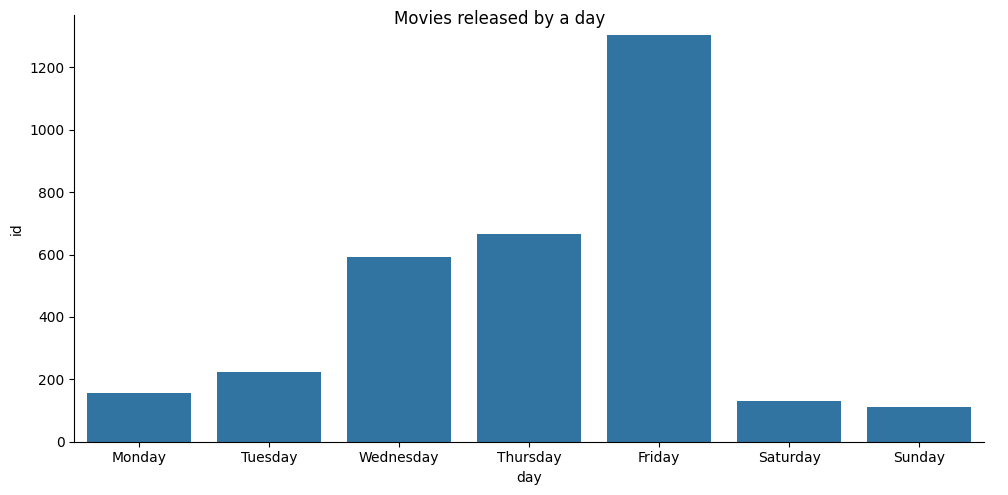

In [128]:
# The number of movies by a day of the week.
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

byADay = sns.catplot(
    data = moviesWithDateTime.groupby('day')['id'].count().to_frame().reset_index(),
    x = 'day',
    y = 'id',
    kind = 'bar',
    order = order,
    aspect = 2
)

byADay.figure.suptitle('Movies released by a day')

moviesWithDateTime.groupby('day')['id'].count().to_frame().reset_index()

### **4.1.2 The number of movies released by a month**

Movies are released the most on Sebtember,  
and the fewest movies are released on November.

Movies tend to be released  more frequently as the year moves toward its end.


,month,id
0,April,219
1,August,277
2,December,335
3,February,222
4,January,187
5,July,258
6,June,289
7,March,236
8,May,244
9,November,254


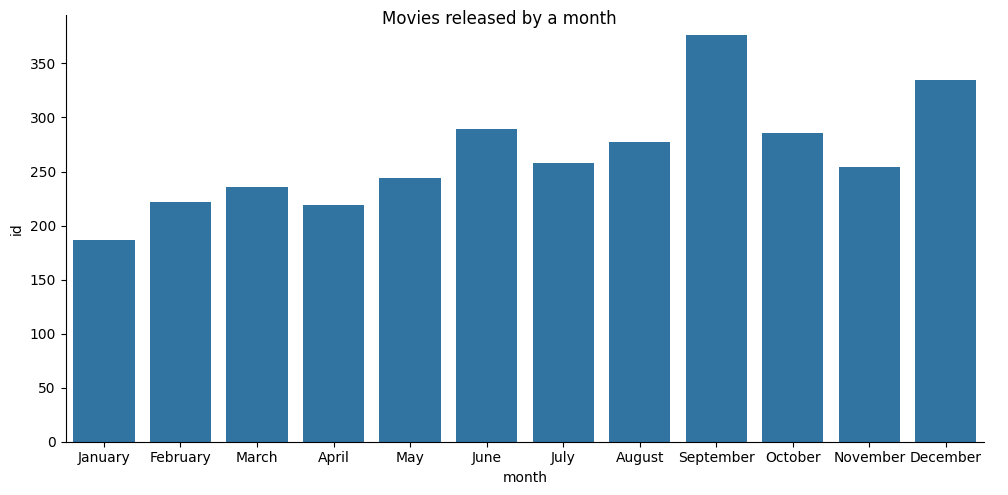

In [129]:
# The number of movies released by a month

order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

byAMonth = sns.catplot(
    data = moviesWithDateTime.groupby('month')['id'].count().to_frame().reset_index(),
    x = 'month',
    y = 'id',
    kind = 'bar',
    order = order,
    aspect = 2
)
byAMonth.figure.suptitle('Movies released by a month')

moviesWithDateTime.groupby('month')['id'].count().to_frame().reset_index()

### **4.1.3 The number of movies released by a year**

As the time passes, the number of movies being released increases steadily.  
In the graph below, movies releases grow almost exponentially.

The lastet movie in the data was released in 2017,  
so the number of movies that are released in 2010s is likely lower than  
the actual total number because the data does not include the full decade.

,decade,id
0,1910,1
1,1920,3
2,1930,14
3,1940,20
4,1950,25
5,1960,58
6,1970,81
7,1980,202
8,1990,535
9,2000,1303


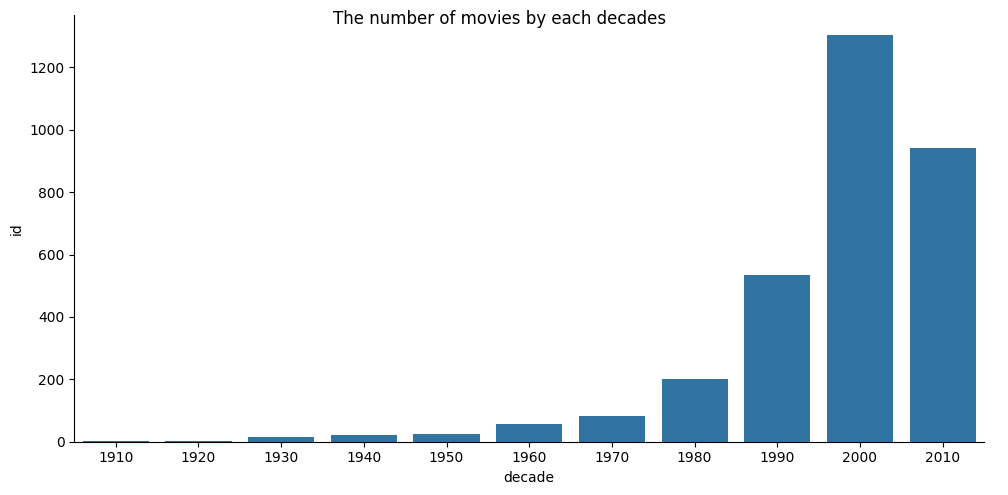

In [130]:
# The number of movies released by a year

# The 'decade' column is used to group movies into 10-year intervals.
moviesWithDateTime['decade'] = (moviesWithDateTime['year'] // 10) * 10

byAMonth = sns.catplot(
    data = moviesWithDateTime.groupby('decade')['id'].count().to_frame().reset_index(),
    x = 'decade',
    y = 'id',
    kind = 'bar',
    aspect = 2
)
byAMonth.figure.suptitle('The number of movies by each decades')

moviesWithDateTime.groupby('decade')['id'].count().to_frame().reset_index()

## **4.2 (2) Genre trend over time**
We tried to analyze the movie genre trend over decades, by sorting how many movies of particular genre are made.

For conciseness, a bar graph has used to indicate the top 3 genres that had made the most.

We had several insights, but the most obvious point was that the movie market was the **most active in 2000's** than any other decades.
Also, **Drama was one of the most popular** genres across all time periods.

In [131]:
# Extracted release year from release date column
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year

movies[["release_date", "release_year"]].head()

,release_date,release_year
0,2009-12-10,2009
1,2007-05-19,2007
2,2015-10-26,2015
3,2012-07-16,2012
4,2012-03-07,2012


In [132]:
# made a distinct genre list
genreList = []
for val in movies["genres"]:
    if pd.isna(val):
        genreList.append([])
        continue

    try:
        parsed = ast.literal_eval(val)
    except (ValueError, SyntaxError):
        genreList.append([])
        continue

    if isinstance(parsed, list):
        genreList.append(
            [d.get("name") for d in parsed if isinstance(d, dict)]
        )
    else:
        genreList.append([])

movies["genre_names"] = genreList
genreDf = movies.explode("genre_names").rename(columns={"genre_names": "genre"})

# changed release year to decades
genreDf = genreDf.dropna(subset=["release_year"])
genreDf["decade"] = (genreDf["release_year"] // 10) * 10

# genre counts for each decades
genreDecadeCounts = (
    genreDf
    .groupby(["decade", "genre"])
    .size()
    .reset_index(name="count")
)

# Extracted only top 3 among them and made a df
top3 = (
    genreDecadeCounts
    .sort_values(["decade", "count"], ascending=[True, False])
    .groupby("decade")
    .head(3)
    .copy()
)

top3["rank"] = top3.groupby("decade")["count"].cumcount() + 1

top3

,decade,genre,count,rank
0,1910,Drama,1,1
1,1920,Drama,3,1
3,1920,Romance,2,2
2,1920,Music,1,3
9,1930,Comedy,7,1
10,1930,Drama,7,2
15,1930,Romance,7,3
21,1940,Drama,13,1
27,1940,Romance,6,2
22,1940,Family,4,3


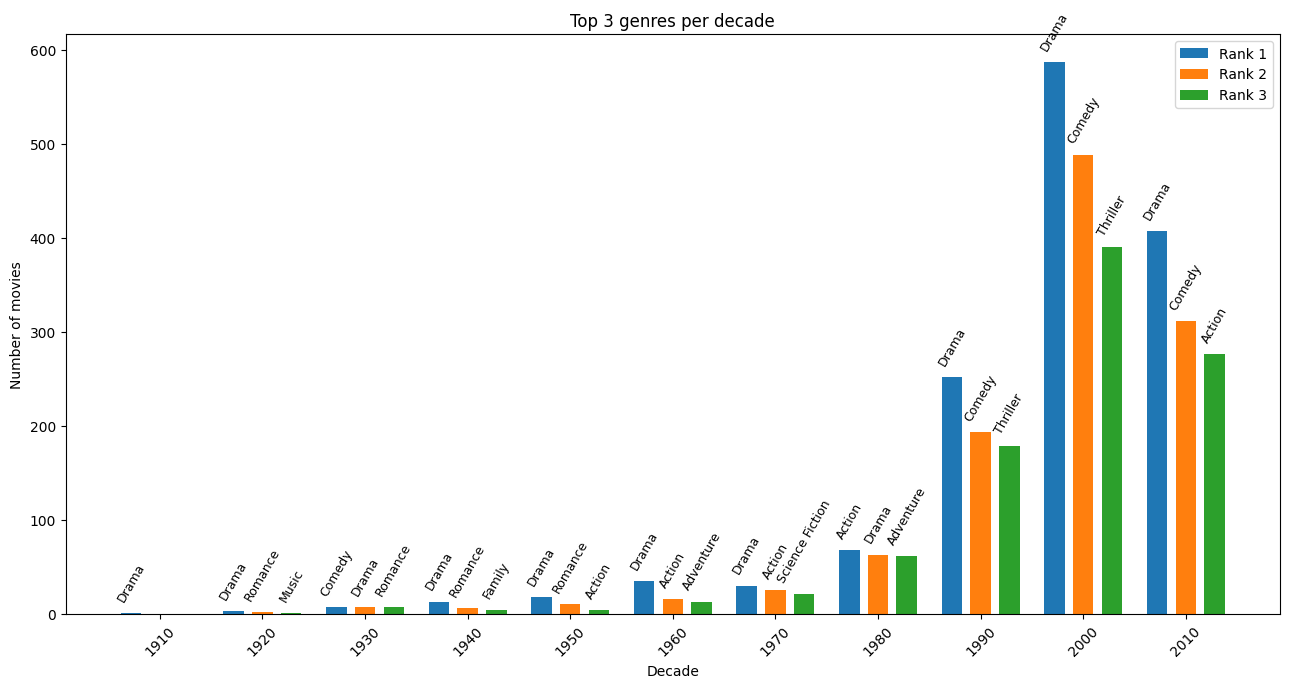

In [133]:
# bar plot
barPositions = {} 

decades = sorted(top3["decade"].unique())
ranks = [1, 2, 3]

pivot = top3.pivot(index="decade", columns="rank", values="count").reindex(decades)
x = np.arange(len(decades))

barWidth = 0.2
innerGap = 0.08
groupWidth = len(ranks) * barWidth + (len(ranks) - 1) * innerGap

plt.figure(figsize=(13, 7))

for i, r in enumerate(ranks):
    heights = pivot[r].values

    positions = (
        x - groupWidth / 2              
        + barWidth / 2                  
        + i * (barWidth + innerGap)    
    )
    

    barPositions[r] = positions 

    plt.bar(positions, heights, width = barWidth, label = f"Rank {r}")

plt.xticks(x, decades, rotation = 45)
plt.xlabel("Decade")
plt.ylabel("Number of movies")
plt.title("Top 3 genres per decade")

plt.legend()

# text positions
for i, decade in enumerate(decades):
    for j, r in enumerate(ranks):
        row = top3[(top3["decade"] == decade) & (top3["rank"] == r)]
        if not row.empty:
            genreName = row["genre"].iloc[0]
            count = row["count"].iloc[0]
            xpos = barPositions[r][i]
            ypos = count + 10
            plt.text(xpos, ypos, genreName, ha="center", va="bottom", rotation=60, fontsize=9)

plt.tight_layout()
plt.show()

## **4.3 (3) Budget vs. Revenue**
Above two analysis were based on the questions of the instruction, but now we would like to find another interesting insight.

This analysis will focus on calculating and ranking movies by their Return on Investment (Revenue/Budget), excluding all non-commercial zero-value entries. The process involves creating a new ROI ratio column, followed by sorting the dataset to identify the most financially efficient productions.
***

In ranking Top 10, there were data errors as we learned from the lecture slides. When you see the budget column, there are some values that seems to be nonsense, such as **1, 10, 218**. 

We searched those movie budgets on google by our own, and found out that they were **`$`1.5M, `$`10M, and `$`218** each. Surprising thing was that the movie **Tarnation** was actually one of the famous low-budget made movies.

However, the **Modern Times** and **Nurse 3-D** can concluded that this error likely originated from negligence on the part of the data entry personnel or the platform itself. The correct values should have been entered with consideration for the units, or the platform should have properly conducted unit conversion during the process of data refinement and management.
***

So if the first two are excluded from the ranking, **Paranormal Activity** would be the movie having highest ROI.

In [134]:
moviesRoi = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)].copy()

moviesRoi['ROI_ratio'] = moviesRoi['revenue'] / moviesRoi['budget']

moviesRoi['genres'] = moviesRoi['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

bestRoiMovies = moviesRoi.sort_values(by = 'ROI_ratio', ascending = False).head(10)

print(bestRoiMovies[['title', 'release_year', 'genre_names', 'budget', 'revenue', 'ROI_ratio']])

                             title  release_year  \
3046                  Modern Times          1936   
2513                     Nurse 3-D          2013   
3131           Paranormal Activity          2007   
3116       The Blair Witch Project          1999   
3173                    Eraserhead          1977   
3179                Pink Flamingos          1972   
3175                 Super Size Me          2004   
3172                   The Gallows          2015   
3120                    Open Water          2004   
2524  The Texas Chain Saw Massacre          1974   

                                    genre_names  budget    revenue  \
3046                            [Drama, Comedy]       1    8500000   
2513                         [Horror, Thriller]      10   10000000   
3131                          [Horror, Mystery]   15000  193355800   
3116                          [Horror, Mystery]   60000  248000000   
3173  [Drama, Fantasy, Horror, Science Fiction]   10000    7000000   
3179   

## **4.4 (4) Correlation Between Features**

This heatmap, including both numeric and non-numeric features below reveals that which features strongly or weakly affect movie revenue.

Features having strong correlations with revenue:
- popularity
- vote_count
- budget
- meanRevenuePerCountry

Features having weak correlations with revenue:
- numberOfCrews
- meanRevenuePerCountry
- vote_average

It is noticeable that features having the lowest correlation with revenue is vote_average, so this will not be used while traning models.

<Axes: >

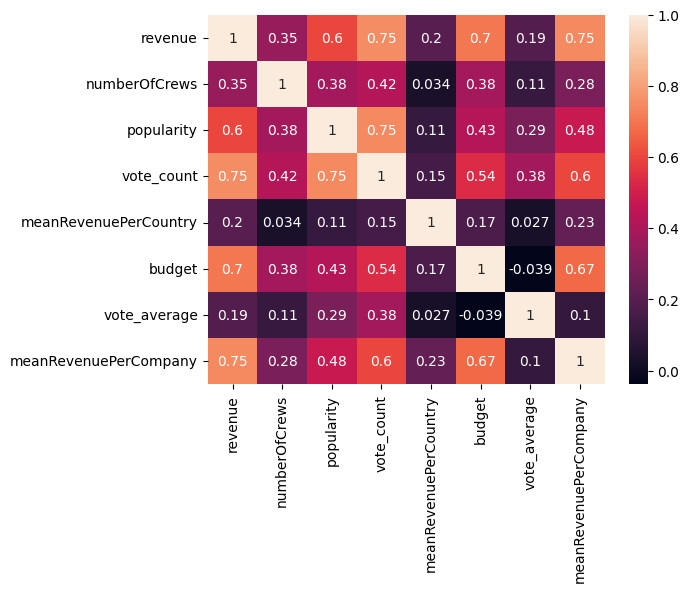

In [135]:
correlations = movies[['revenue',
                   'numberOfCrews',
                   'popularity',
                   'vote_count',
                   'meanRevenuePerCountry',
                   'budget',
                   'vote_average',
                   'meanRevenuePerCompany'
                   ]].corr()
correlations

# create a heatmap
sns.heatmap(correlations, annot = True)

# **5 Build Models**

Three models will be used:
- Simple linear regression (baseline model)
- Multiple linear regression
- Polynomial regression

For cross-validation, data will be split based on:
- movies released before vs. after 2010
- random sampling

How each model work?

**Simple linear regression**
- Evaluate a straight line to the data. The model assumes the relationship between x and y is linear and finds the optimistic parameters a and b in y = ax + b  
by minimizing the least squares error between predicted and actual values, as taught in the lecture. 

**Multiple linear regression**  
- Although the model is still linear, it uses multiple input variables unlike simple linear regression.
- Each variable has its own independent coefficient (weight).
- The form of equation will be: y = a_0 + a_0x_0 + a_1x_1 + ... + a_nx_n
- Using methods such as least squares, the model calculates the coefficients and the intercept that minimize the total prediction error. 

**Polynomial regression**  
- Now the relationship between inputs and a target does not guarantee a linearity.
- When multiple input variables exist, then polynomial regression considers combinations of input variables  
(a multiplication of them for example; x_1 * x_2) to capture complex patterns and improve model performance.

**Feature Variables used in training**
- Log Budget
- Popularity
- Vote count
- Number of Crews
- Log mean revenue per Country
- Log Mean revenue per production company

**Variables used for visualization of results**
- Log Budget (x-axis)
- Log Revenue (y-axis)

Budget was used as x-axis in the result graphs because the RSE difference between models using budget and vote_count was minimal (around 0.0xx), suggesting similar predictive performace.  

Although vote_count has a higher correlation, budget still works well as it captures multiple underlyung aspects of a film's production.  

Log transformation was applied to both revenue and budget for scale reduction.

## **5.1 Case 1: Split data for training and testing models (Before vs. after 2010)**

**Training set:**  
Data before 2010’s ( ~ 2009)  

**Testing set:**  
Data of 2010’s (2010 ~ )  


**Targeting:**  
Prediction of every revenue in 2010’s  

This time-based split is resonable because it simulates a real-world scenario **(using past data to predict future outcomes)**.

In [136]:
# Extract data which will be used for training
trainingMovies = movies[movies['release_date'].dt.year < 2010].copy()
testingMovies = movies[movies['release_date'].dt.year >= 2010].copy()

### **5.1.1 Train Baseline Model - Linear Regression**

The following model will be a baseline model for predicting movie revenue by using only one feature, budgets.

Equation:
- y =  0.7643952053191282 * x + 4.667164913993144

**RSE using training data : 1.5531**


Equation: 
y =  0.7643952053191282 * x + 4.667164913993144


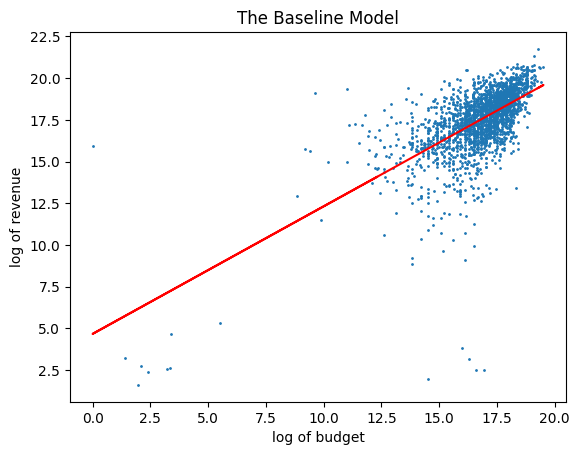

RSE: 1.5531147381099775


In [137]:
from scipy import stats
# create a base line model using linear regression from scipy stats.
# https://www.w3schools.com/python/python_ml_linear_regression.asp

# use log to normalize data
trainingMovies['logBudget'] = np.log(trainingMovies['budget'])
trainingMovies['logRevenue'] = np.log(trainingMovies['revenue'])

x = trainingMovies['logBudget']
y = trainingMovies['logRevenue']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
    return slope * x + intercept

# linear regression equation using scipy stats
print("Equation: ")
print("y = ", str(slope), "* x +", str(intercept))
mymodel = list(map(myfunc, x))

# The data graph including the linear regression function
plt.scatter(x, y, s = 1)
plt.plot(x, mymodel, color = "red")
plt.xlabel("log of budget")
plt.ylabel("log of revenue")
plt.title("The Baseline Model")
plt.show()

# Calculate RSE using traningMovies
prediectedY = myfunc(x)
n = len(y)
RSE = np.sqrt(np.sum((y - prediectedY)**2) / (n - 2))
print("RSE:", RSE)


### **5.1.1 Test the baseline model**

Since the equation of the baseline model has been computed, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using testing data: 1.5213**

Since the model follows a linear form y = ax + b, it is visually clear that the predicted values differ noticeably from the actual values.  
Revenue cannot be predicted accurately by only a single feature like budget. 

RSE:  1.5213008203615246


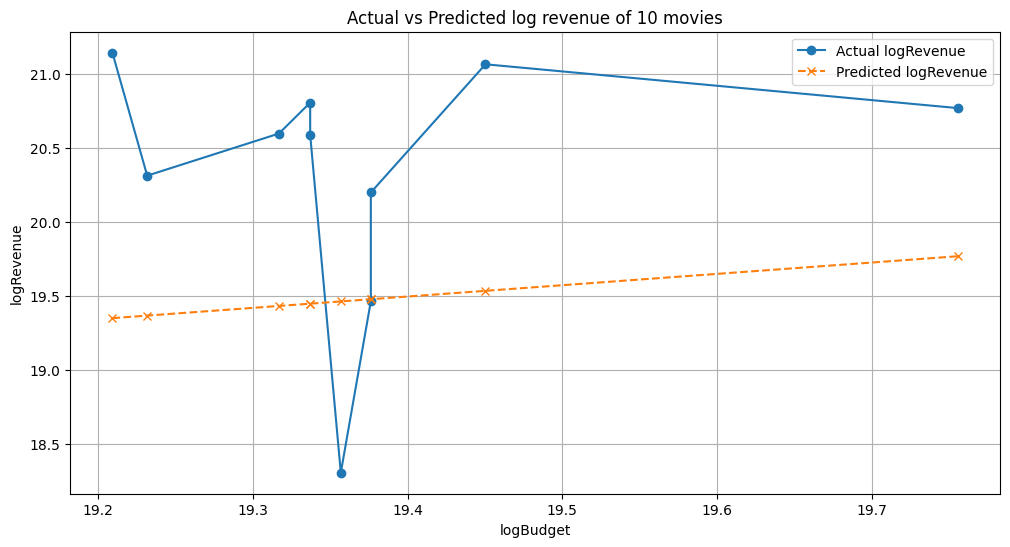

In [138]:
# movies released after 2010.
testingMovies

# use log to normalize datas
testingMovies['logBudget'] = np.log(testingMovies['budget'])
testingMovies['logRevenue'] = np.log(testingMovies['revenue'])


y_tested = myfunc(testingMovies['logBudget'])
y_tested
testingMovies['logRevenue']

# RSE using testing data
n = len(y_tested)
RSE = np.sqrt(np.sum((y_tested - testingMovies['logRevenue'])**2) / (n - 2))
print("RSE: ", RSE)

testingMovies['predicted_logRevenue'] = y_tested
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label = 'Actual logRevenue', marker = 'o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label = 'Predicted logRevenue', linestyle = '--', marker = 'x')
plt.title('Actual vs Predicted log revenue of 10 movies')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()


### **5.1.2 Train Multiple Linear Regression model**

Based on the previous data analysis, the heatmap showed that movie revenue is correlated not only with budget but also with several other features.  
Therefore, the multiple linear regression model will be used to estimate the revenue more accrurately, using multiple features.

**RSE using testing data: 1.1953**

In [139]:
from sklearn import linear_model

# take log of meanRevenuePerCountry to normalize the data
trainingMovies['logMeanRevenuePerCountry'] = np.log(trainingMovies['meanRevenuePerCountry'])
trainingMovies['logMeanRevenuePerCompany'] = np.log(trainingMovies['meanRevenuePerCompany'])

testingFeatures = ['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']
x = trainingMovies[testingFeatures]
y = trainingMovies['logRevenue']

regr = linear_model.LinearRegression()
regr.fit(x, y)

print("Weights (w_i):", regr.coef_)
print("Intercept (w_0):", regr.intercept_)

y_pred = regr.predict(x)
RSE = np.sqrt(np.sum((y - y_pred)**2) / (len(y) - 6 - 1))
print("RSE: ", RSE)

Weights (w_i): [4.53440337e-01 2.04840487e-02 2.16889044e-05 7.84954029e-04
 3.79815925e-03 6.63771875e-01]
Intercept (w_0): -2.866255162514438
RSE:  1.1952733098056751


### **5.1.2 Test the multiple regression model**

Since the multiple regression model has been trained, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using training data: 1.4588**

The RSE of the testing data is higher than that of the training data.  
This indicates that the movie industry changed after 2010, meaning that a model trained only on movies released before 2010 cannot fully capture the  revenue patterns of movies released after 2010.


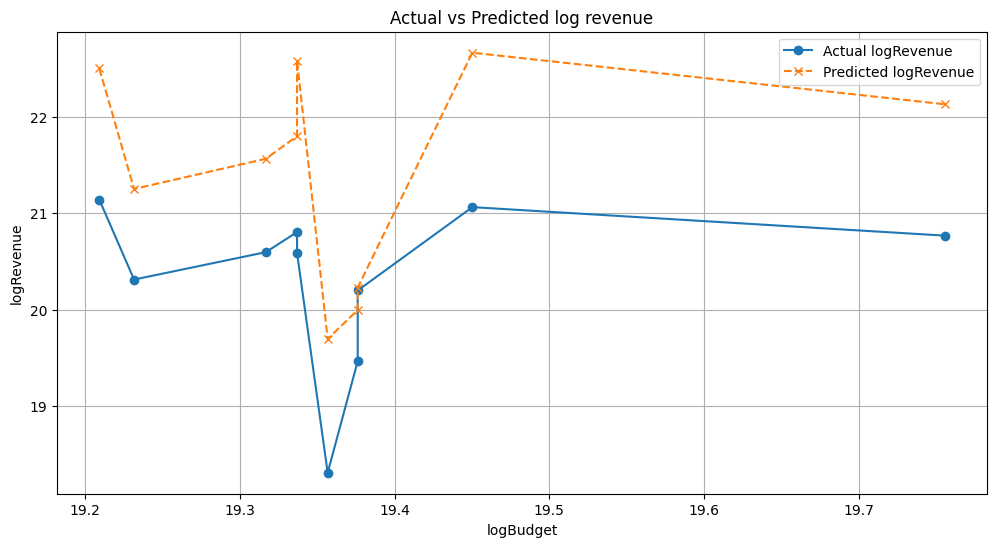

In [140]:
# movies released after 2010.
testingMovies

# take log of meanRevenuePerCountry to normalize the data
testingMovies['logMeanRevenuePerCountry'] = np.log(testingMovies['meanRevenuePerCountry'])
testingMovies['logMeanRevenuePerCompany'] = np.log(testingMovies['meanRevenuePerCompany'])

testingY_pred = regr.predict(testingMovies[testingFeatures])

# RSE using testing data
n = len(testingY_pred)
RSE = np.sqrt(np.sum((testingY_pred - testingMovies['logRevenue'])**2) / (n - 6 - 1))
RSE

testingMovies['predicted_logRevenue'] = testingY_pred
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label = 'Actual logRevenue', marker = 'o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label = 'Predicted logRevenue', linestyle = '--', marker = 'x')
plt.title('Actual vs Predicted log revenue')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()


### **5.1.3 Train Polynomial Regression model**

Since we have already estimated movie revenues using a multiple linear regression model with several features, we now investigate whether a polynomial relationship between revenue and features produces better results.  
Therefore, a polynomial regression model will be employed to estimate the revenue more accurately using the same set of features.

**RSE using training data when degree = 2 and alpha = 1**
- 1.0803

Degree of 2 and alpha of 1 were selected because these provide the best balance between complexity and stability of the polynomial model (Optimistic values for bias-variance tradeoffs).

In [141]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

x = trainingMovies[['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']]
y = trainingMovies['logRevenue']

poly = PolynomialFeatures(degree = 2, include_bias = False)

# create feature matrix
scaler = StandardScaler()
scaledX = scaler.fit_transform(x)
x = poly.fit_transform(scaledX)

# train models
model = Ridge(alpha = 1)
model.fit(x, y)

# collect predicted results
y_predicted = model.predict(x)

result = pd.DataFrame({
    'logBudget' : trainingMovies['logBudget'],
    'y_predicted' : y_predicted
})
        
# residual sum of squares (RSS)
n = len(y) 
RSE = np.sqrt(np.sum((y - y_predicted) ** 2) / (n - 6 - 1))
print("RSE:", RSE)

RSE: 1.0803132909493016


### **5.1.3 Test the polynomial regression model**

Since the polynomial regression model has been trained, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using training data: 1.9158**

The RSE of the testing data turned out to be higher than the RSE of the training data.  

Similar to the results from multiple linear regression, the model does not capture  the changed  tendency of movies released after 2010.  
The gap between the RSE of training and testing data becomes larger when compared to the RSEs from the multiple linear regression model.  
This model is more complex, which increases the risk of overfitting, resulting in high variance on the testing data.


RSE:  1.9157873105581031


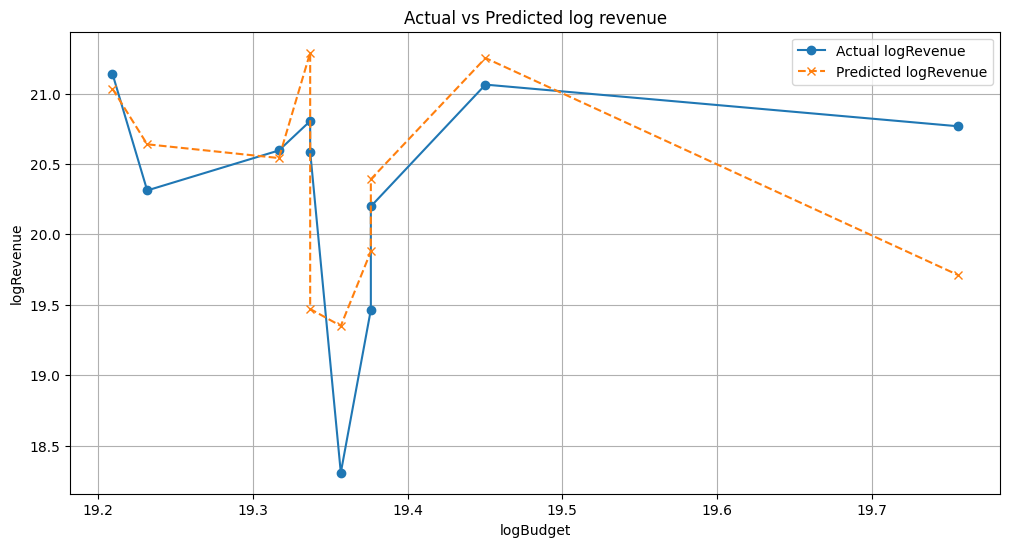

In [142]:
# movies released after 2010.
testingMovies

x = testingMovies[['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']]
y = testingMovies['logRevenue']

scaledX = scaler.transform(x)
x = poly.transform(scaledX)

testingY_pred = model.predict(x)
# print(testingY_pred)

# RSE using testing data
n = len(testingY_pred)
RSE = np.sqrt(np.sum((y - testingY_pred)**2) / (n - 6 - 2))
print("RSE: ", RSE)

testingMovies['predicted_logRevenue'] = testingY_pred
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label='Actual logRevenue', marker='o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label='Predicted logRevenue', linestyle='--', marker='x')
plt.title('Actual vs Predicted log revenue')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()


## **5.2 Case 2: Split data for training and testing models (Random Sampling)**

**Training set:**    
Randomly selected 70% from whole data  

**Testing set:**  
Rest 30% of whole data


**Targeting:**   
Prediction of every revenue in randomly selected data


The movies used to train and test the models will be selected randomly.

In [143]:
from sklearn.model_selection import train_test_split

# movie data is randomly split
trainingMovies, testingMovies = train_test_split(movies, test_size = 0.3, random_state = 42)

### **5.2.1 Train Baseline Model - Linear Regression**

The following model will be a baseline model for predicting movie revenue by using only one feature, budgets.

Equation:
y =  0.8202 * x + 3.7123  
 
**RSE using training data : 1.5715**

Equation: 
y =  0.8201548222806377 * x 3.712439557949196


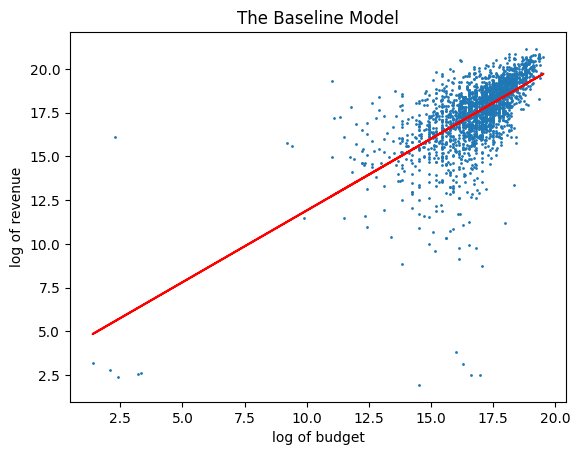

RSE: 1.5714900813703614


In [144]:
# use log to normalize data
trainingMovies['logBudget'] = np.log(trainingMovies['budget'])
trainingMovies['logRevenue'] = np.log(trainingMovies['revenue'])

x = trainingMovies['logBudget']
y = trainingMovies['logRevenue']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
    return slope * x + intercept

# linear regression equation using scipy stats
print("Equation: ")
print("y = ", str(slope), "* x", str(intercept))
mymodel = list(map(myfunc, x))

# The data graph including the linear regression function
plt.scatter(x, y, s = 1)
plt.plot(x, mymodel, color = "red")
plt.xlabel("log of budget")
plt.ylabel("log of revenue")
plt.title("The Baseline Model")
plt.show()

# Calculate RSE using traningMovies
prediectedY = myfunc(x)
n = len(y)
RSE = np.sqrt(np.sum((y - prediectedY)**2) / (n - 2))
print("RSE:", RSE)

### **5.2.1 Test the baseline model**

Since the equation of the baseline model has been computed, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using testing data: 1.4723**

The result is similar from the result of the simple linear regression model in Case 1.  
Since this is a linear model, it is clear that the actual and expected revenue form a noticeable gap.


RSE:  1.4722642507679031


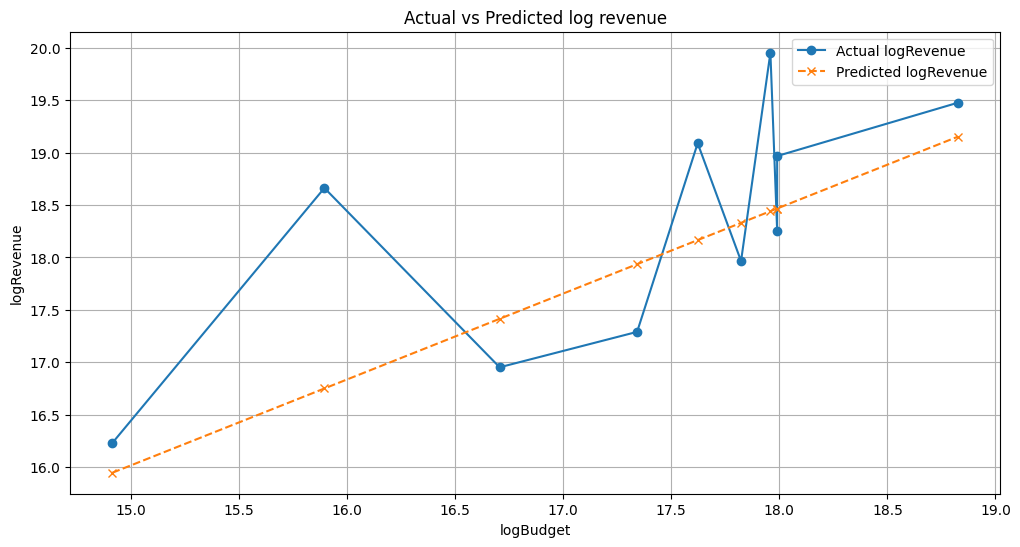

In [145]:
# movies released after 2010.
testingMovies

# use log to normalize datas
testingMovies['logBudget'] = np.log(testingMovies['budget'])
testingMovies['logRevenue'] = np.log(testingMovies['revenue'])


y_tested = myfunc(testingMovies['logBudget'])
y_tested
testingMovies['logRevenue']

# RSE using testing data
n = len(y_tested)
RSE = np.sqrt(np.sum((y_tested - testingMovies['logRevenue'])**2) / (n - 2))
print("RSE: ", RSE)

testingMovies['predicted_logRevenue'] = y_tested
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label='Actual logRevenue', marker='o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label='Predicted logRevenue', linestyle='--', marker='x')
plt.title('Actual vs Predicted log revenue')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()

### **5.2.2 Train Multiple Linear Regression model**

Based on the previous data analysis, the heatmap showed that movie revenue is correlated not only with budget but also with several other features.  
Therefore, the multiple linear regression model will be used to estimate the revenue more accrurately, using multiple features.

**RSE using testing data: 1.2195**

In [146]:
# take log of meanRevenuePerCountry to normalize the data
trainingMovies['logMeanRevenuePerCountry'] = np.log(trainingMovies['meanRevenuePerCountry'])
trainingMovies['logMeanRevenuePerCompany'] = np.log(trainingMovies['meanRevenuePerCompany'])

testingFeatures = ['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']
x = trainingMovies[testingFeatures]
y = trainingMovies['logRevenue']

regr = linear_model.LinearRegression()
regr.fit(x, y)

print("Weights (w_i):", regr.coef_)
print("Intercept (b):", regr.intercept_)

y_pred = regr.predict(x)
RSE = np.sqrt(np.sum((y - y_pred)**2) / (len(y) - 6 - 1))
print("RSE: ", RSE)

Weights (w_i): [4.35727292e-01 2.84434175e-03 2.11255595e-04 1.43318432e-03
 2.44930312e-01 7.29667980e-01]
Intercept (b): -8.062627364037464
RSE:  1.219510619982789


### **5.2.2 Test the multiple regression model**

Since the multiple regression model has been trained, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using testing data: 1.1299**

The RSE gap between the training and testing data becomes smaller in the random split when compared to Case 1.  
Since the training and testing data are not biased toward any specific time period or a group in Case 2,  
it leads to more balanced and consistent RSE results.


RSE:  1.1299491393214658


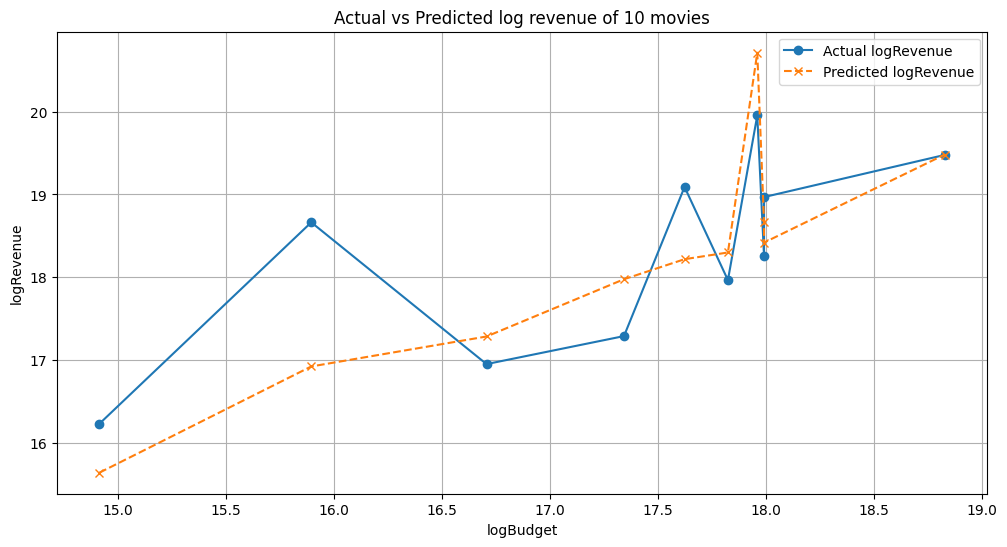

In [147]:
# movies released after 2010.
testingMovies

# take log of meanRevenuePerCountry to normalize the data
testingMovies['logMeanRevenuePerCountry'] = np.log(testingMovies['meanRevenuePerCountry'])
testingMovies['logMeanRevenuePerCompany'] = np.log(testingMovies['meanRevenuePerCompany'])

testingY_pred = regr.predict(testingMovies[testingFeatures])

# RSE using testing data
n = len(testingY_pred)
RSE = np.sqrt(np.sum((testingY_pred - testingMovies['logRevenue'])**2) / (n - 6 - 1))
print("RSE: ", RSE)

# compare acutal vs predicted log revenue
testingMovies['predicted_logRevenue'] = testingY_pred
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label='Actual logRevenue', marker='o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label='Predicted logRevenue', linestyle='--', marker='x')
plt.title('Actual vs Predicted log revenue of 10 movies')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()

### **5.2.3 Train Polynomial Regression model**

Since we have already estimated movie revenues using a multiple linear regression model with several features, we now investigate whether a polynomial relationship between revenue and features produces better results.  
Therefore, a polynomial regression model will be employed to estimate the revenue more accurately using the same set of features.

A degree of 2 will be used.


Alpha of 2500 will be used.

**RSE using training data:**
- 1.1206

In [148]:
x = trainingMovies[['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']]
y = trainingMovies['logRevenue']

poly = PolynomialFeatures(degree = 2, include_bias = False)

# create feature matrix
scaler = StandardScaler()
scaledX = scaler.fit_transform(x)
x = poly.fit_transform(scaledX)

# train models
model = Ridge(alpha = 1)
model.fit(x, y)

# collect predicted results
y_predicted = model.predict(x)

result = pd.DataFrame({
    'logBudget' : trainingMovies['logBudget'],
    'y_predicted' : y_predicted
})
        
# residual sum of squares (RSS)
n = len(y) 
RSE = np.sqrt(np.sum((y - y_predicted) ** 2) / (n - 6 - 1))
print("RSE:", RSE)

RSE: 1.1205604798267783


### **5.2.3 Test the polynomial regression model**

Since the polynomial regression model has been trained, it is possible to evaluate how model is accurate by comparing the actual revenues with the revenues predicted by the model.

**RSE using testing data: 1.1961**

The RSE using polynomial regression is smaller than the RSE of linear regression when observing the training data, like Case 1. 

Conversely, the RSE using polynomial regression is higher than the RSE of linear regression when observing the testing data, like Case 1.


RSE:  1.195487457148468


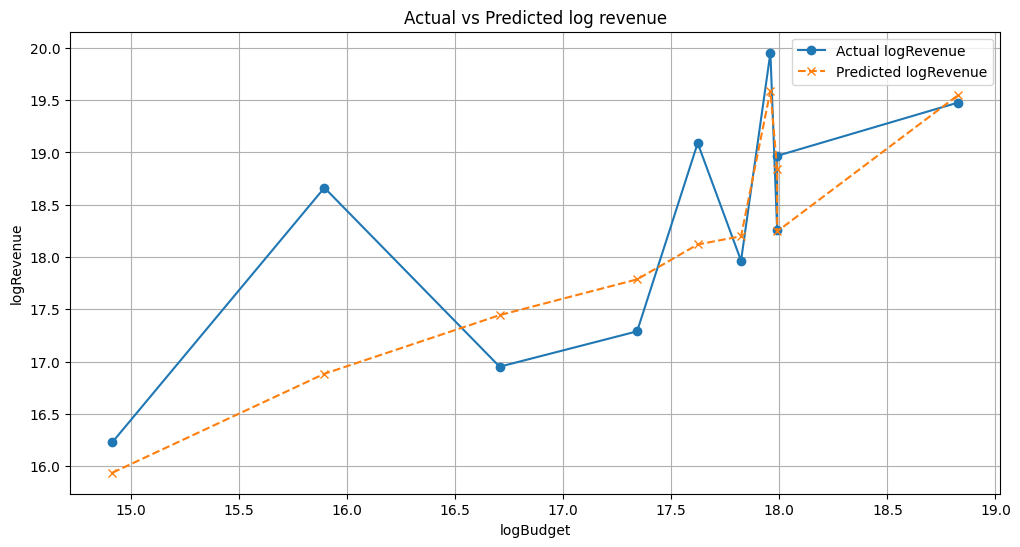

In [149]:
# movies released after 2010.
testingMovies

x = testingMovies[['logBudget', 'popularity', 'vote_count', 'numberOfCrews', 'logMeanRevenuePerCountry', 'logMeanRevenuePerCompany']]
y = testingMovies['logRevenue']

scaledX = scaler.transform(x)
x = poly.transform(scaledX)

testingY_pred = model.predict(x)
# print(testingY_pred)

# RSE using testing data
n = len(testingY_pred)
RSE = np.sqrt(np.sum((y - testingY_pred)**2) / (n - 6 - 1))
print("RSE: ", RSE)


testingMovies['predicted_logRevenue'] = testingY_pred
top10Movies = testingMovies.head(10)
top10Movies = top10Movies.sort_values(by = 'logBudget')

plt.figure(figsize=(12, 6))
plt.plot(top10Movies['logBudget'], top10Movies['logRevenue'], label = 'Actual logRevenue', marker = 'o')
plt.plot(top10Movies['logBudget'], top10Movies['predicted_logRevenue'], label = 'Predicted logRevenue', linestyle = '--', marker = 'x')
plt.title('Actual vs Predicted log revenue')
plt.xlabel('logBudget')
plt.ylabel('logRevenue')
plt.legend()
plt.grid(True)
plt.show()

# Result (RSE)

The RSE decreased as we used more complex models while training.  
It is reasonable that the RSE becomes smaller as the models use more complex calculations. 

However, the lowest RSE of test data came from the linear regression model.  
It is conjectured that this is because complex calculations were fit to the training data, so that polynomial regression resulted in a higher error for the testing data compared to the linear regression model.


In [150]:
rseOfTrainingData = {
    "Model": ["Baseline Model", "Multiple Linear Regression", "Polynomial Regression"],
    "Split Before/After 2010": [1.5531, 1.1953, 1.0803],
    "Polynomial Reression": [1.5715, 1.2195, 1.1206]
}
pd.DataFrame(rseOfTrainingData)

,Model,Split Before/After 2010,Polynomial Reression
0,Baseline Model,1.5531,1.5715
1,Multiple Linear Regression,1.1953,1.2195
2,Polynomial Regression,1.0803,1.1206


In [151]:
resOfTestingData = {
    "Model": ["Baseline Model", "Multiple Linear Regression", "Polynomial Regression"],
    "Split Before/After 2010": [1.5123, 1.4588, 1.9158],
    "Polynomial Reression": [1.4723, 1.1299, 1.1961]
}
pd.DataFrame(resOfTestingData)

,Model,Split Before/After 2010,Polynomial Reression
0,Baseline Model,1.5123,1.4723
1,Multiple Linear Regression,1.4588,1.1299
2,Polynomial Regression,1.9158,1.1961


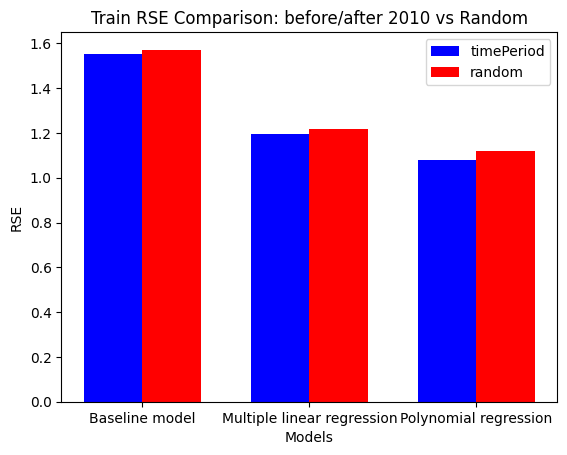

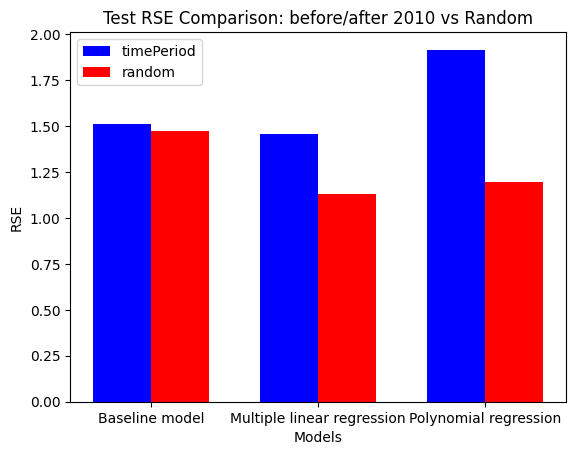

In [152]:
label = ['Baseline model', 'Multiple linear regression', 'Polynomial regression']
trainingRseByTimePeriod = [1.5531, 1.1953, 1.0803]
trainingRseByRandom = [1.5715, 1.2195, 1.1206]

testingRseByTimePeriod = [1.5123, 1.4588, 1.9158]
testingRseByRandom = [1.4723, 1.1299, 1.1961]

# cross validation with the training RSE.
x = np.arange(len(label))
barWidth = 0.35
plt.bar(x - barWidth / 2, trainingRseByTimePeriod, width = barWidth, label = 'timePeriod', color = 'blue')
plt.bar(x + barWidth / 2, trainingRseByRandom, width = barWidth, label = 'random', color = 'red')
plt.xticks(x, label)
plt.xlabel('Models')
plt.ylabel('RSE')
plt.title('Train RSE Comparison: before/after 2010 vs Random')
plt.legend()
plt.show()


# cross validation with the testing RSE.
plt.bar(x - barWidth / 2, testingRseByTimePeriod, width = barWidth, label = 'timePeriod', color = 'blue')
plt.bar(x + barWidth / 2, testingRseByRandom, width = barWidth, label = 'random', color = 'red')
plt.xticks(x, label)
plt.xlabel('Models')
plt.ylabel('RSE')
plt.title('Test RSE Comparison: before/after 2010 vs Random')
plt.legend()
plt.show()

# **Conlcusion**

1. Data Splitting Strategy significantly influences performance
- Case 1:  
When the data was divided by decades, the predicted curve followed a similar overall trend to the actual data,  
the predicted values were not close to the true values.  
It failed to capture the changes in the scale of the film industry and the actual growth of the market over a certain amount of time.  
This indicates a limitation in analyzing the problem using only the given dataset.  

- Case 2:  
On the other hand, the prediction using randomly split data was not affected by time, but was made only with the data itself.  
This derived a result having low RSE, though the tendency of case 1 seemed better than the one of case 2.

2. Multiple Linear regression record the lowest overall RSE
At first, we thought that the polynomial regression model would have make the best prediction  
since it does the most complicated calculations among the three models.
However it gave us a result worse than the multiple linear regression model because it was vulnerable to overfitting.

3. Future Improvement
In addition to movie data, time related information such as theater attendance numbers and Netflix  
subscriber counts would likely lead to more accurate results.
Applying a more stable feature normalization method is necessary to achieve more accurate results in polynomial regression.
